<a href="https://colab.research.google.com/github/Md819-max/BTC-price-predict/blob/main/ML_April17_BTC_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


📥 Downloading BTC data for BTC-USD...

✅ Data loaded: 1567 rows
Latest available date: 2026-04-16
Price range: $15,787.28 to $124,752.53

🔧 Features created successfully
Total engineered features: 40

Walk-forward fold 1: train=1061, valid=75
Walk-forward fold 2: train=1136, valid=75
Walk-forward fold 3: train=1211, valid=75
Walk-forward fold 4: train=1286, valid=75
Walk-forward fold 5: train=1361, valid=75
Walk-forward fold 6: train=1436, valid=75

 WALK-FORWARD MODEL COMPARISON
           Model         MAE        RMSE     MAPE       R2
           Ridge 1584.351556 2180.917218 1.706308 0.830758
LinearRegression 1595.870757 2196.248724 1.718623 0.829054
         XGBoost 3737.158325 4521.005219 3.759159 0.181038
GradientBoosting 3975.991957 4961.581311 4.113092 0.108957
    RandomForest 4090.354725 5141.753524 4.295171 0.084024

🏆 Best model selected: Ridge

 FINAL TEST PERFORMANCE (Ridge)
MAE   : $1,604.65
RMSE  : $2,235.71
MAPE  : 1.85%
R²    : 0.9839

 BTC NEXT-DAY FORECAST
Latest a

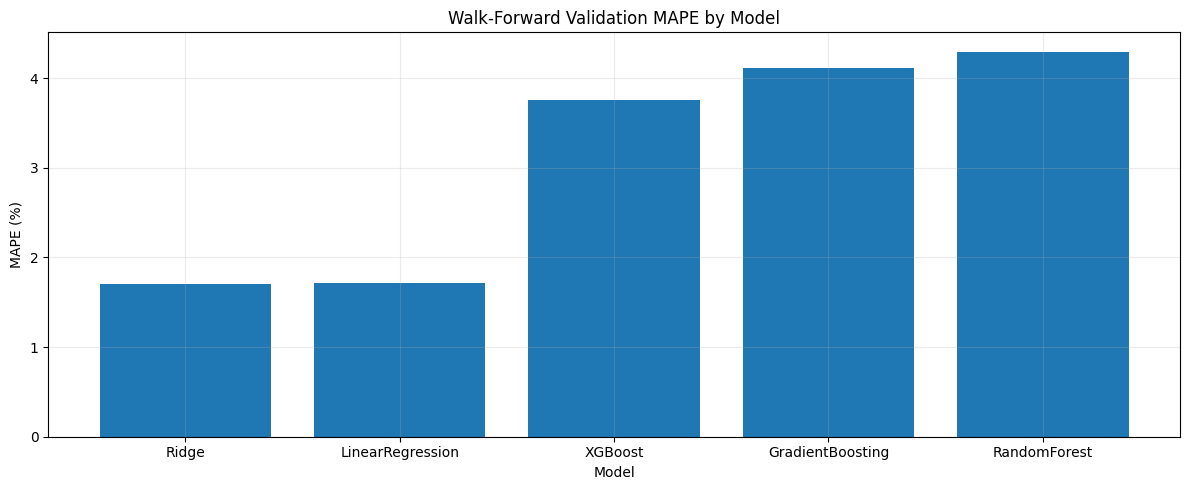

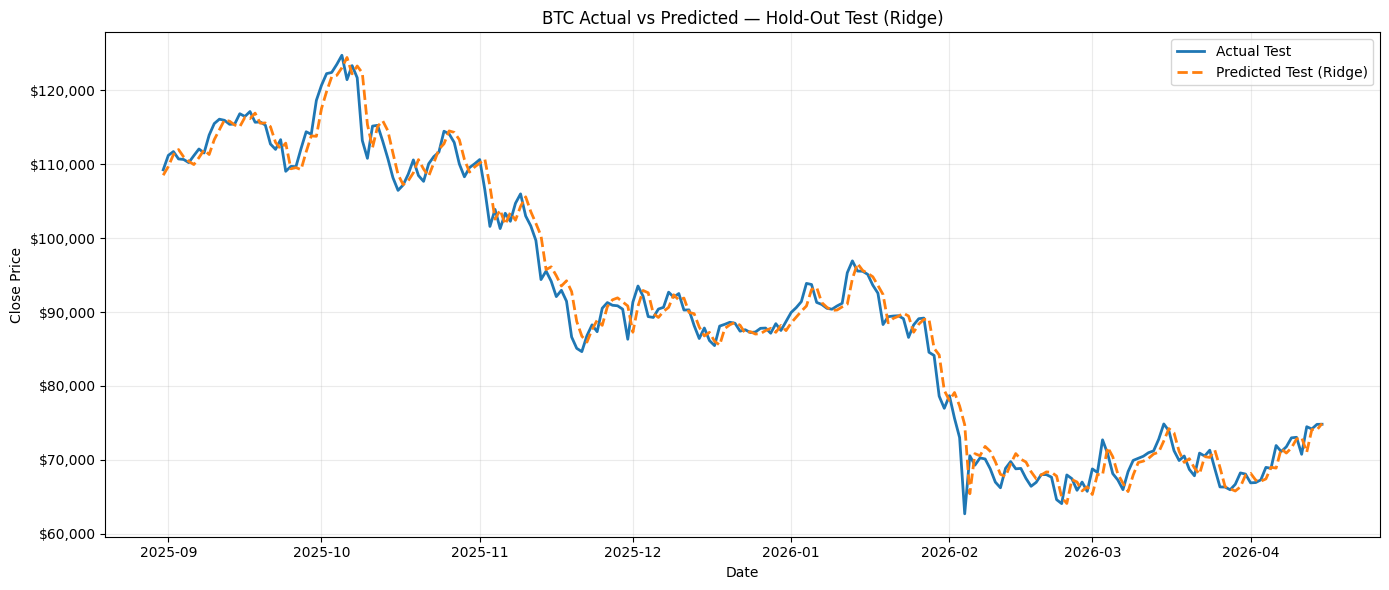

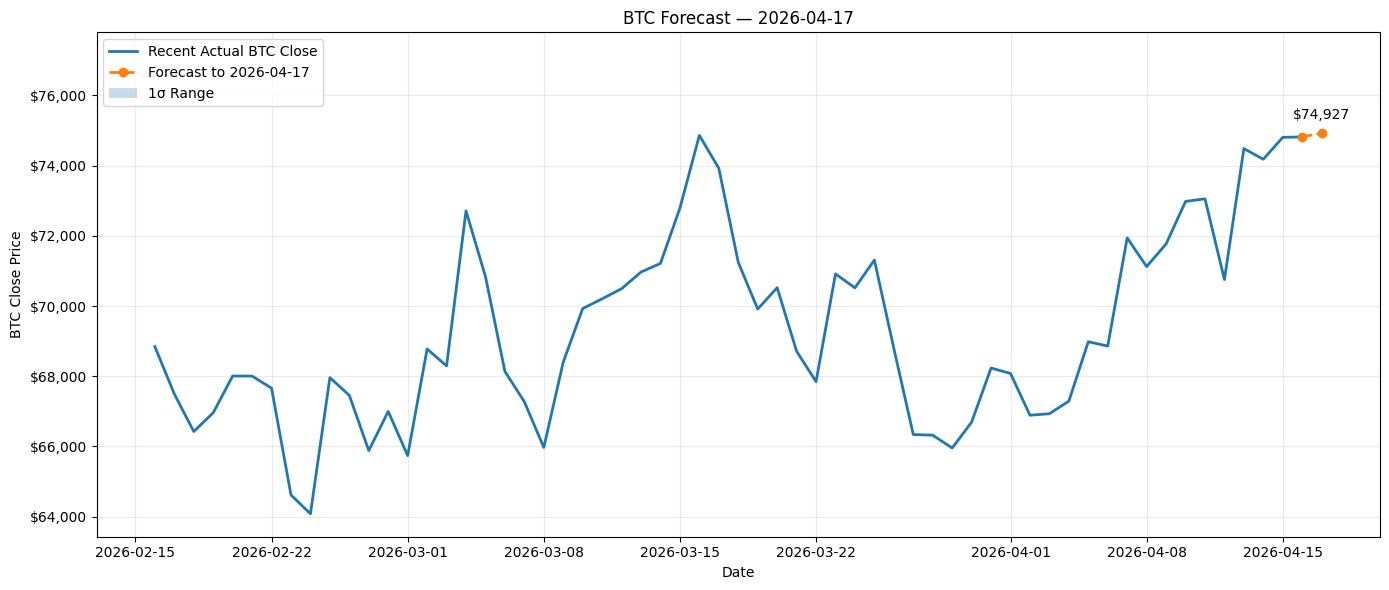


📁 Forecast summary saved as 'btc_forecast_apr17_2026_advanced_walkforward.csv'


In [ ]:
"""
BTC Price Prediction — Advanced Walk-Forward Forecasting Project
================================================================
Forecast target: April 17, 2026

Advanced Enhancements:
1. Better feature engineering
2. Multiple model comparison
3. Walk-forward time-series validation
4. Optional XGBoost support
5. Safer next-day forecast logic
6. Prediction interval using residual volatility
7. Cleaner charts and summary output

Libraries:
- yfinance
- pandas
- numpy
- matplotlib
- sklearn
- xgboost (optional)
"""

import warnings
warnings.filterwarnings("ignore")

import yfinance as yf
import pandas as pd
import numpy as np
!pip install xgboost
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Optional XGBoost
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False


# =============================================================================
# SETTINGS
# =============================================================================
TICKER = "BTC-USD"
START_DATE = "2022-01-01"
TARGET_FORECAST_DATE = pd.Timestamp("2026-04-17")
CURRENCY = "$"

# yfinance end is exclusive
YF_END_DATE = TARGET_FORECAST_DATE.strftime("%Y-%m-%d")

# walk-forward config
INITIAL_TRAIN_RATIO = 0.70
VALID_WINDOW_RATIO = 0.05   # rolling validation chunk size
USE_XGBOOST = True          # will only work if xgboost is installed


# =============================================================================
# STEP 1: DOWNLOAD DATA
# =============================================================================
print(f"\n📥 Downloading BTC data for {TICKER}...\n")

df = yf.download(
    TICKER,
    start=START_DATE,
    end=YF_END_DATE,
    auto_adjust=True,
    progress=False
)

if df.empty:
    raise ValueError(f"No data found for ticker {TICKER}")

if isinstance(df.columns, pd.MultiIndex):
    df.columns = [col[0] for col in df.columns]

df = df[["Close"]].copy()
df.dropna(inplace=True)

df["Close"] = pd.to_numeric(df["Close"], errors="coerce")
df.dropna(inplace=True)

print(f"✅ Data loaded: {len(df)} rows")
print(f"Latest available date: {df.index[-1].date()}")
print(f"Price range: {CURRENCY}{df['Close'].min():,.2f} to {CURRENCY}{df['Close'].max():,.2f}\n")


# =============================================================================
# STEP 2: FEATURE ENGINEERING
# =============================================================================
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi


def create_features(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()

    # lags
    for lag in [1, 2, 3, 5, 7, 14, 21]:
        data[f"Lag_{lag}"] = data["Close"].shift(lag)

    # moving averages
    for ma in [5, 10, 20, 30, 50]:
        data[f"MA_{ma}"] = data["Close"].rolling(ma).mean()

    # exponential moving averages
    data["EMA_5"] = data["Close"].ewm(span=5, adjust=False).mean()
    data["EMA_12"] = data["Close"].ewm(span=12, adjust=False).mean()
    data["EMA_26"] = data["Close"].ewm(span=26, adjust=False).mean()

    # MACD
    data["MACD"] = data["EMA_12"] - data["EMA_26"]
    data["MACD_Signal"] = data["MACD"].ewm(span=9, adjust=False).mean()
    data["MACD_Hist"] = data["MACD"] - data["MACD_Signal"]

    # Bollinger bands
    rolling_20 = data["Close"].rolling(20)
    data["BB_Mid"] = rolling_20.mean()
    data["BB_Std"] = rolling_20.std()
    data["BB_Upper"] = data["BB_Mid"] + 2 * data["BB_Std"]
    data["BB_Lower"] = data["BB_Mid"] - 2 * data["BB_Std"]
    data["BB_Width"] = (data["BB_Upper"] - data["BB_Lower"]) / data["BB_Mid"]

    # returns
    data["Daily_Return"] = data["Close"].pct_change()
    for p in [3, 7, 14]:
        data[f"Return_{p}"] = data["Close"].pct_change(p)

    # volatility
    for v in [5, 10, 20]:
        data[f"Volatility_{v}"] = data["Daily_Return"].rolling(v).std()

    # momentum
    for m in [3, 7, 14]:
        data[f"Momentum_{m}"] = data["Close"] - data["Close"].shift(m)

    # RSI
    data["RSI_14"] = compute_rsi(data["Close"], 14)

    # price position features
    data["Price_vs_MA5"] = data["Close"] / data["MA_5"]
    data["Price_vs_MA20"] = data["Close"] / data["MA_20"]
    data["Price_vs_MA50"] = data["Close"] / data["MA_50"]

    # calendar features
    data["DayOfWeek"] = data.index.dayofweek
    data["Month"] = data.index.month
    data["Quarter"] = data.index.quarter

    # target
    data["Target"] = data["Close"].shift(-1)

    data.dropna(inplace=True)
    return data


df_feat = create_features(df)

feature_columns = [col for col in df_feat.columns if col not in ["Close", "Target"]]

X = df_feat[feature_columns].copy()
y = df_feat["Target"].copy()

print("🔧 Features created successfully")
print(f"Total engineered features: {len(feature_columns)}\n")


# =============================================================================
# STEP 3: DEFINE MODELS
# =============================================================================
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(
        n_estimators=400,
        max_depth=12,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=400,
        learning_rate=0.03,
        max_depth=3,
        random_state=42
    )
}

if USE_XGBOOST and XGBOOST_AVAILABLE:
    models["XGBoost"] = XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=42
    )


# =============================================================================
# STEP 4: WALK-FORWARD VALIDATION
# =============================================================================
def fit_and_predict(model_name, model, X_train, y_train, X_valid):
    """
    Linear models use scaling, tree models use raw values.
    """
    if model_name in ["LinearRegression", "Ridge"]:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_valid_scaled = scaler.transform(X_valid)
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_valid_scaled)
        return pred, scaler
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_valid)
        return pred, None


def walk_forward_evaluation(X, y, models, initial_train_ratio=0.70, valid_window_ratio=0.05):
    n = len(X)
    initial_train_size = int(n * initial_train_ratio)
    valid_window_size = max(10, int(n * valid_window_ratio))

    all_results = []
    model_fold_predictions = {}

    for model_name in models:
        model_fold_predictions[model_name] = {
            "actuals": [],
            "preds": [],
            "dates": []
        }

    fold = 1
    train_end = initial_train_size

    while train_end + valid_window_size <= n:
        valid_end = train_end + valid_window_size

        X_train = X.iloc[:train_end]
        y_train = y.iloc[:train_end]
        X_valid = X.iloc[train_end:valid_end]
        y_valid = y.iloc[train_end:valid_end]

        print(f"Walk-forward fold {fold}: train={len(X_train)}, valid={len(X_valid)}")

        for model_name, model in models.items():
            pred, _ = fit_and_predict(model_name, model, X_train, y_train, X_valid)

            mae = mean_absolute_error(y_valid, pred)
            rmse = np.sqrt(mean_squared_error(y_valid, pred))
            mape = np.mean(np.abs((y_valid - pred) / y_valid)) * 100
            r2 = r2_score(y_valid, pred)

            all_results.append({
                "Fold": fold,
                "Model": model_name,
                "MAE": mae,
                "RMSE": rmse,
                "MAPE": mape,
                "R2": r2
            })

            model_fold_predictions[model_name]["actuals"].extend(y_valid.tolist())
            model_fold_predictions[model_name]["preds"].extend(pred.tolist())
            model_fold_predictions[model_name]["dates"].extend(X_valid.index.tolist())

        train_end = valid_end
        fold += 1

    results_df = pd.DataFrame(all_results)

    summary_df = (
        results_df
        .groupby("Model")[["MAE", "RMSE", "MAPE", "R2"]]
        .mean()
        .sort_values("MAPE")
        .reset_index()
    )

    return results_df, summary_df, model_fold_predictions


fold_results_df, summary_results_df, model_fold_predictions = walk_forward_evaluation(
    X, y, models,
    initial_train_ratio=INITIAL_TRAIN_RATIO,
    valid_window_ratio=VALID_WINDOW_RATIO
)

print("\n" + "=" * 95)
print(" WALK-FORWARD MODEL COMPARISON")
print("=" * 95)
print(summary_results_df.to_string(index=False))
print("=" * 95)

best_model_name = summary_results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print(f"\n🏆 Best model selected: {best_model_name}\n")


# =============================================================================
# STEP 5: HOLD-OUT TEST SET FOR FINAL EVALUATION
# =============================================================================
n = len(X)
train_valid_end = int(n * 0.85)

X_train_valid = X.iloc[:train_valid_end]
y_train_valid = y.iloc[:train_valid_end]

X_test = X.iloc[train_valid_end:]
y_test = y.iloc[train_valid_end:]

if best_model_name in ["LinearRegression", "Ridge"]:
    scaler_final = StandardScaler()
    X_train_valid_scaled = scaler_final.fit_transform(X_train_valid)
    X_test_scaled = scaler_final.transform(X_test)

    best_model.fit(X_train_valid_scaled, y_train_valid)
    y_test_pred = best_model.predict(X_test_scaled)
else:
    scaler_final = None
    best_model.fit(X_train_valid, y_train_valid)
    y_test_pred = best_model.predict(X_test)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mape = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100
test_r2 = r2_score(y_test, y_test_pred)

print("=" * 95)
print(f" FINAL TEST PERFORMANCE ({best_model_name})")
print("=" * 95)
print(f"MAE   : {CURRENCY}{test_mae:,.2f}")
print(f"RMSE  : {CURRENCY}{test_rmse:,.2f}")
print(f"MAPE  : {test_mape:.2f}%")
print(f"R²    : {test_r2:.4f}")
print("=" * 95)


# =============================================================================
# STEP 6: BUILD NEXT FEATURE ROW
# =============================================================================
def build_next_feature_row_from_close(close_series: pd.Series, feature_columns: list) -> pd.DataFrame:
    temp = pd.DataFrame({"Close": close_series.copy()})
    feat_temp = create_features(temp)

    if feat_temp.empty:
        raise ValueError("Not enough historical data to build next feature row.")

    next_row = feat_temp[feature_columns].iloc[[-1]].copy()
    return next_row


latest_feature_row = build_next_feature_row_from_close(df["Close"], feature_columns)


# =============================================================================
# STEP 7: NEXT-DAY FORECAST
# =============================================================================
if best_model_name in ["LinearRegression", "Ridge"]:
    latest_scaled = scaler_final.transform(latest_feature_row)
    forecast_price = float(best_model.predict(latest_scaled)[0])
else:
    forecast_price = float(best_model.predict(latest_feature_row)[0])

last_actual_date = df.index[-1]
last_actual_price = float(df["Close"].iloc[-1])

predicted_change = forecast_price - last_actual_price
predicted_change_pct = (predicted_change / last_actual_price) * 100

if predicted_change > 0:
    trend = "UP"
elif predicted_change < 0:
    trend = "DOWN"
else:
    trend = "FLAT"


# =============================================================================
# STEP 8: PREDICTION RANGE / CONFIDENCE BAND
# =============================================================================
test_residuals = y_test.values - y_test_pred
residual_std = np.std(test_residuals)

lower_1sigma = forecast_price - residual_std
upper_1sigma = forecast_price + residual_std

lower_2sigma = forecast_price - (2 * residual_std)
upper_2sigma = forecast_price + (2 * residual_std)


print("\n" + "=" * 95)
print(" BTC NEXT-DAY FORECAST")
print("=" * 95)
print(f"Latest available actual date : {last_actual_date.date()}")
print(f"Latest actual close          : {CURRENCY}{last_actual_price:,.2f}")
print(f"Forecast date                : {TARGET_FORECAST_DATE.date()}")
print(f"Predicted close              : {CURRENCY}{forecast_price:,.2f}")
print(f"Predicted change             : {CURRENCY}{predicted_change:+,.2f}")
print(f"Predicted change %           : {predicted_change_pct:+.2f}%")
print(f"Predicted trend              : {trend}")
print(f"1σ range                     : {CURRENCY}{lower_1sigma:,.2f} to {CURRENCY}{upper_1sigma:,.2f}")
print(f"2σ range                     : {CURRENCY}{lower_2sigma:,.2f} to {CURRENCY}{upper_2sigma:,.2f}")
print("=" * 95)


# =============================================================================
# STEP 9: FEATURE IMPORTANCE
# =============================================================================
if best_model_name in ["RandomForest", "GradientBoosting", "XGBoost"]:
    importance_df = pd.DataFrame({
        "Feature": feature_columns,
        "Importance": best_model.feature_importances_
    }).sort_values("Importance", ascending=False).head(15)

    print("\n🔍 Top 15 Important Features:")
    print(importance_df.to_string(index=False))


# =============================================================================
# STEP 10: VISUALIZATION
# =============================================================================
# Chart 1: Average walk-forward MAPE by model
plt.figure(figsize=(12, 5))
plt.bar(summary_results_df["Model"], summary_results_df["MAPE"])
plt.title("Walk-Forward Validation MAPE by Model")
plt.ylabel("MAPE (%)")
plt.xlabel("Model")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# Chart 2: Actual vs predicted on test set
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test.values, label="Actual Test", linewidth=2)
plt.plot(y_test.index, y_test_pred, label=f"Predicted Test ({best_model_name})", linestyle="--", linewidth=2)
plt.title(f"BTC Actual vs Predicted — Hold-Out Test ({best_model_name})")
plt.ylabel("Close Price")
plt.xlabel("Date")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# Chart 3: recent 60 days + forecast + range
recent_actual = df["Close"].tail(60)

plt.figure(figsize=(14, 6))
plt.plot(recent_actual.index, recent_actual.values, linewidth=2, label="Recent Actual BTC Close")
plt.plot(
    [recent_actual.index[-1], TARGET_FORECAST_DATE],
    [recent_actual.iloc[-1], forecast_price],
    marker="o",
    linestyle="--",
    linewidth=2,
    label=f"Forecast to {TARGET_FORECAST_DATE.date()}"
)

plt.fill_between(
    [TARGET_FORECAST_DATE],
    [lower_1sigma],
    [upper_1sigma],
    alpha=0.25,
    label="1σ Range"
)

plt.annotate(
    f"${forecast_price:,.0f}",
    (TARGET_FORECAST_DATE, forecast_price),
    textcoords="offset points",
    xytext=(0, 10),
    ha="center"
)

plt.title(f"BTC Forecast — {TARGET_FORECAST_DATE.date()}")
plt.ylabel("BTC Close Price")
plt.xlabel("Date")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


# =============================================================================
# STEP 11: SAVE OUTPUT
# =============================================================================
forecast_summary = pd.DataFrame([{
    "Forecast_Date": TARGET_FORECAST_DATE.strftime("%Y-%m-%d"),
    "Latest_Actual_Date": last_actual_date.strftime("%Y-%m-%d"),
    "Latest_Actual_Close": round(last_actual_price, 2),
    "Predicted_Close": round(forecast_price, 2),
    "Predicted_Change": round(predicted_change, 2),
    "Predicted_Change_Pct": round(predicted_change_pct, 4),
    "Trend": trend,
    "Best_Model": best_model_name,
    "Test_MAE": round(test_mae, 2),
    "Test_RMSE": round(test_rmse, 2),
    "Test_MAPE": round(test_mape, 4),
    "Test_R2": round(test_r2, 4),
    "Range_1sigma_Lower": round(lower_1sigma, 2),
    "Range_1sigma_Upper": round(upper_1sigma, 2),
    "Range_2sigma_Lower": round(lower_2sigma, 2),
    "Range_2sigma_Upper": round(upper_2sigma, 2)
}])

csv_file = "btc_forecast_apr17_2026_advanced_walkforward.csv"
forecast_summary.to_csv(csv_file, index=False)

print(f"\n📁 Forecast summary saved as '{csv_file}'")


